In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../Dataset/zomato.csv")

# Display first 5 rows
df.head()

,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,0,0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,1,1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,2,2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,3,3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,4,4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


In [141]:
df.shape

(7105, 12)

In [142]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'restaurant name', 'restaurant type',
       'rate (out of 5)', 'num of ratings', 'avg cost (two people)',
       'online_order', 'table booking', 'cuisines type', 'area',
       'local address'],
      dtype='object')

In [143]:
df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)

In [144]:

df.columns

Index(['restaurant name', 'restaurant type', 'rate (out of 5)',
       'num of ratings', 'avg cost (two people)', 'online_order',
       'table booking', 'cuisines type', 'area', 'local address'],
      dtype='object')

In [145]:
df.shape

(7105, 10)

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   restaurant name        7105 non-null   object 
 1   restaurant type        7105 non-null   object 
 2   rate (out of 5)        7037 non-null   float64
 3   num of ratings         7105 non-null   int64  
 4   avg cost (two people)  7048 non-null   float64
 5   online_order           7105 non-null   object 
 6   table booking          7105 non-null   object 
 7   cuisines type          7105 non-null   object 
 8   area                   7105 non-null   object 
 9   local address          7105 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 555.2+ KB


In [147]:
df.isnull().sum()

restaurant name           0
restaurant type           0
rate (out of 5)          68
num of ratings            0
avg cost (two people)    57
online_order              0
table booking             0
cuisines type             0
area                      0
local address             0
dtype: int64

In [148]:
print("Rows before cleaning:", df.shape[0])

df = df.dropna()

print("Rows after cleaning:", df.shape[0])

Rows before cleaning: 7105
Rows after cleaning: 6984


In [149]:

df.isnull().sum()

restaurant name          0
restaurant type          0
rate (out of 5)          0
num of ratings           0
avg cost (two people)    0
online_order             0
table booking            0
cuisines type            0
area                     0
local address            0
dtype: int64

In [150]:
df.shape

(6984, 10)

In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
df.describe()

,rate (out of 5),num of ratings,avg cost (two people)
count,6984.000000,6984.000000,6984.000000
mean,3.514304,190.928837,542.544244
std,0.463489,596.717894,464.266828
min,1.800000,1.000000,40.000000
25%,3.200000,15.000000,300.000000
50%,3.500000,40.000000,400.000000
75%,3.800000,130.000000,600.000000
max,4.900000,16345.000000,6000.000000


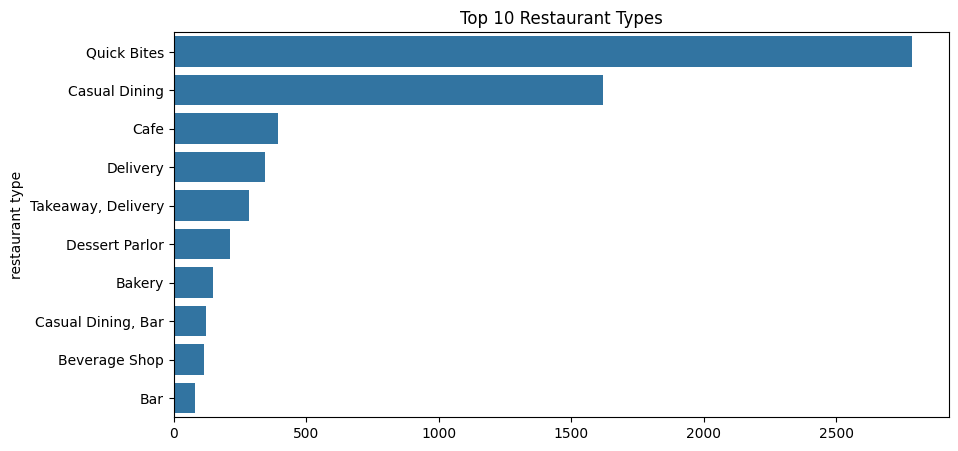

In [153]:
top_types = df['restaurant type'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_types.values,
    y=top_types.index
)

plt.title('Top 10 Restaurant Types')
plt.show()

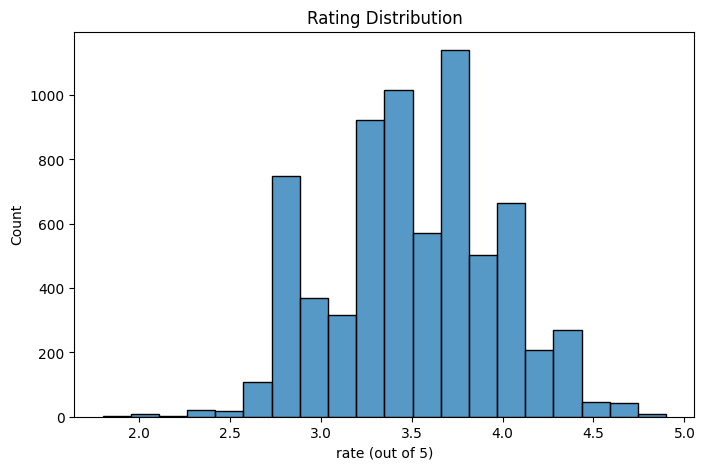

In [154]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['rate (out of 5)'],
    bins=20
)

plt.title('Rating Distribution')
plt.show()

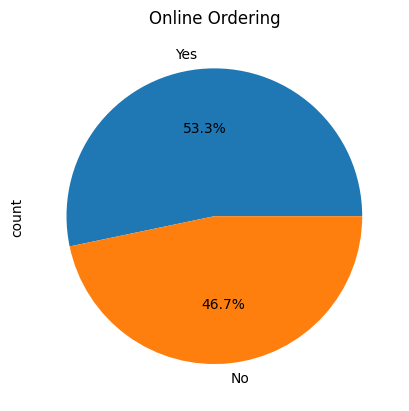

In [155]:
df['online_order'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Online Ordering')
plt.show()

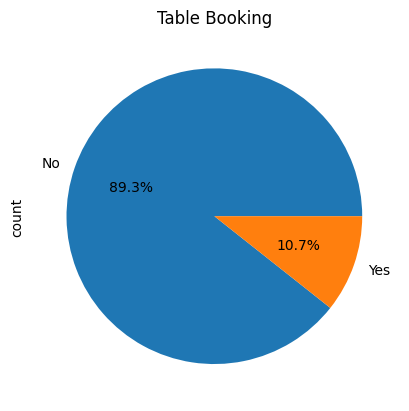

In [156]:
df['table booking'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Table Booking')
plt.show()

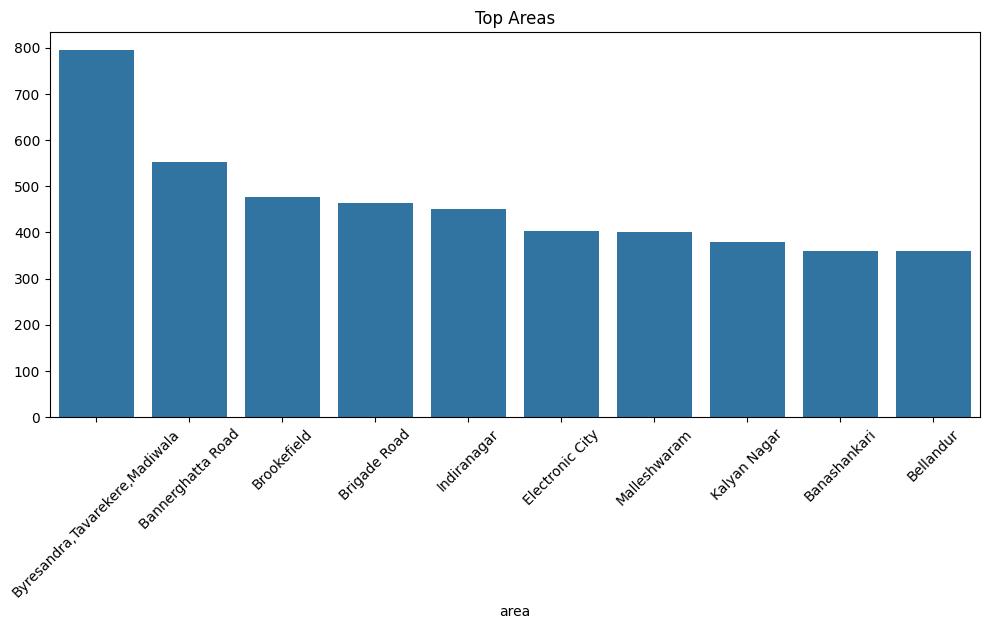

In [157]:
top_area = df['area'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_area.index,
    y=top_area.values
)

plt.xticks(rotation=45)
plt.title('Top Areas')
plt.show()

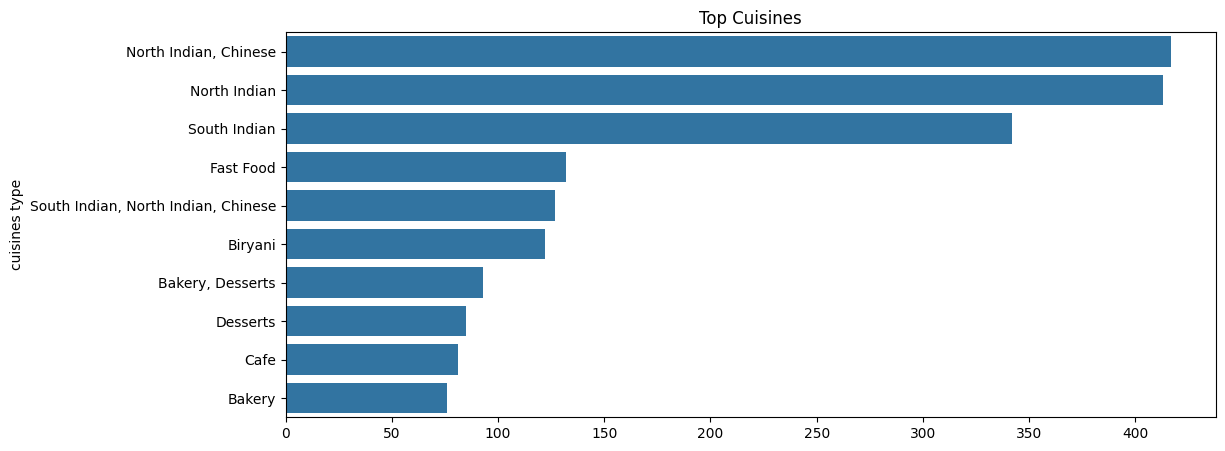

In [158]:
top_cuisine = df['cuisines type'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_cuisine.values,
    y=top_cuisine.index
)

plt.title('Top Cuisines')
plt.show()

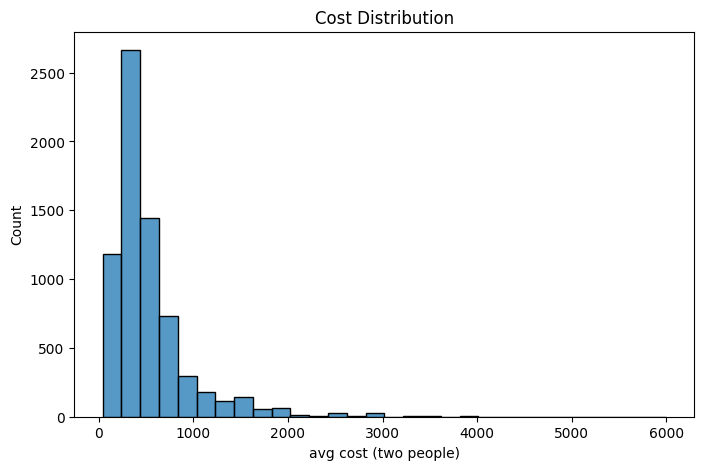

In [159]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['avg cost (two people)'],
    bins=30
)

plt.title('Cost Distribution')
plt.show()

In [160]:
df['Popularity Score'] = (
    df['rate (out of 5)']
    *
    df['num of ratings']
)
top_restaurants = df[
    ['restaurant name',
     'Popularity Score']
].sort_values(
    by='Popularity Score',
    ascending=False
).head(10)

print(top_restaurants)

                  restaurant name  Popularity Score
1035  Byg Brewski Brewing Company           80090.5
6665                         Toit           70293.2
6242              The Black Pearl           48941.1
770                   Big Pitcher           42651.2
423         Arbor Brewing Company           37687.5
4808               Prost Brew Pub           35343.0
2149                     Flechazo           33623.8
6380    The Hole in the Wall Cafe           32719.8
1489         Church Street Social           32439.2
757                    Biergarten           32265.5


In [161]:
df['restaurant type'].value_counts().head(10)

restaurant type
Quick Bites           2784
Casual Dining         1620
Cafe                   395
Delivery               346
Takeaway, Delivery     283
Dessert Parlor         212
Bakery                 149
Casual Dining, Bar     121
Beverage Shop          115
Bar                     81
Name: count, dtype: int64

In [162]:
df['online_order'].value_counts()

online_order
Yes    3721
No     3263
Name: count, dtype: int64

In [163]:
df['table booking'].value_counts()

table booking
No     6240
Yes     744
Name: count, dtype: int64

In [164]:
df['area'].value_counts().head(10)

area
Byresandra,Tavarekere,Madiwala    794
Bannerghatta Road                 552
Brookefield                       477
Brigade Road                      463
Indiranagar                       450
Electronic City                   402
Malleshwaram                      401
Kalyan Nagar                      379
Banashankari                      359
Bellandur                         359
Name: count, dtype: int64

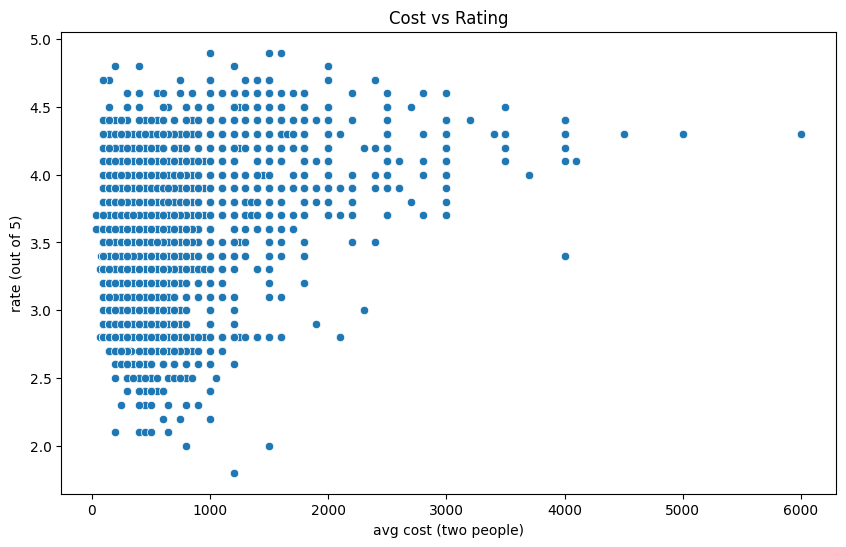

In [165]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='avg cost (two people)',
    y='rate (out of 5)'
)

plt.title('Cost vs Rating')
plt.show()

In [166]:
df['Popularity Score'] = (
    df['rate (out of 5)'] *
    df['num of ratings']
)


In [167]:
df[['restaurant name',
    'Popularity Score']].sort_values(
    by='Popularity Score',
    ascending=False
).head(10)

,restaurant name,Popularity Score
1035,Byg Brewski Brewing Company,80090.5
6665,Toit,70293.2
6242,The Black Pearl,48941.1
770,Big Pitcher,42651.2
423,Arbor Brewing Company,37687.5
4808,Prost Brew Pub,35343.0
2149,Flechazo,33623.8
6380,The Hole in the Wall Cafe,32719.8
1489,Church Street Social,32439.2
757,Biergarten,32265.5


In [168]:
df.groupby('online_order')['rate (out of 5)'].mean()

online_order
No     3.471345
Yes    3.551975
Name: rate (out of 5), dtype: float64

In [169]:
df.groupby('table booking')['rate (out of 5)'].mean()

table booking
No     3.452099
Yes    4.036022
Name: rate (out of 5), dtype: float64

In [170]:
df.to_csv(
    "../Dataset/cleaned_zomato.csv",
    index=False
)

In [171]:
import sqlite3

conn = sqlite3.connect("../Database/zomato.db")
df.to_sql(
    "zomato",
    conn,
    if_exists="replace",
    index=False
)

print("Cleaned data loaded into SQLite")

Cleaned data loaded into SQLite


In [172]:
query = """
SELECT COUNT(*) AS Total_Restaurants
FROM zomato;
"""

total_restaurants = pd.read_sql_query(
    query,
    conn
)

total_restaurants

,Total_Restaurants
0,6984


In [173]:
query = """
SELECT area,
       COUNT(*) AS Total_Restaurants
FROM zomato
GROUP BY area
ORDER BY Total_Restaurants DESC
LIMIT 10;
"""

top_areas_sql = pd.read_sql_query(
    query,
    conn
)

top_areas_sql

,area,Total_Restaurants
0,"Byresandra,Tavarekere,Madiwala",794
1,Bannerghatta Road,552
2,Brookefield,477
3,Brigade Road,463
4,Indiranagar,450
5,Electronic City,402
6,Malleshwaram,401
7,Kalyan Nagar,379
8,Bellandur,359
9,Banashankari,359


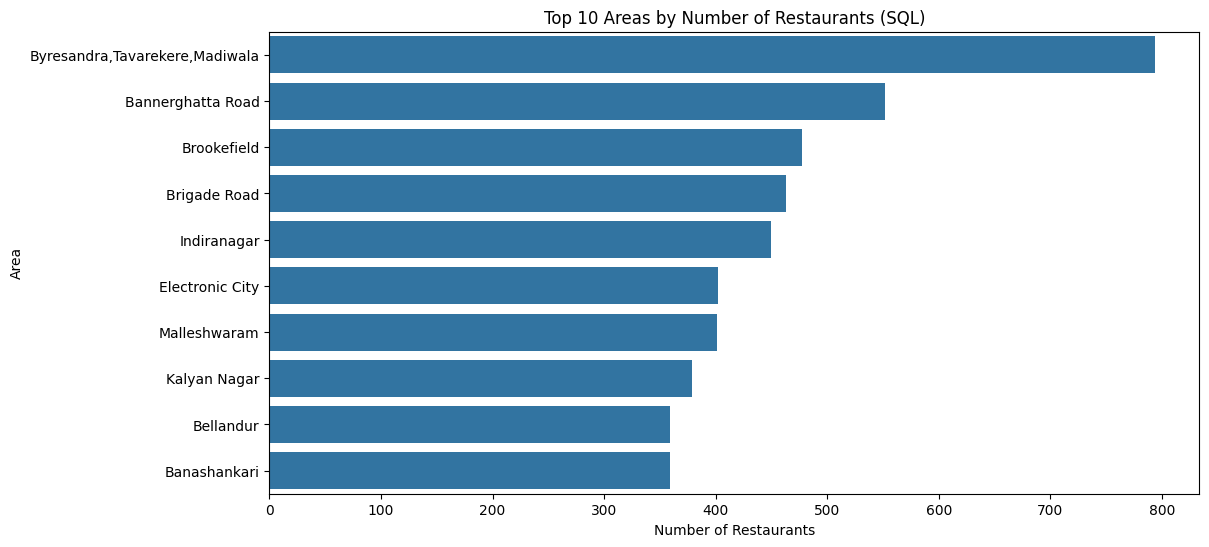

In [174]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_areas_sql,
    x="Total_Restaurants",
    y="area"
)

plt.title("Top 10 Areas by Number of Restaurants (SQL)")
plt.xlabel("Number of Restaurants")
plt.ylabel("Area")

plt.show()

In [175]:
query = """
SELECT online_order,
       AVG([rate (out of 5)]) AS Avg_Rating
FROM zomato
GROUP BY online_order;
"""

online_rating_sql = pd.read_sql_query(
    query,
    conn
)

online_rating_sql

,online_order,Avg_Rating
0,No,3.471345
1,Yes,3.551975


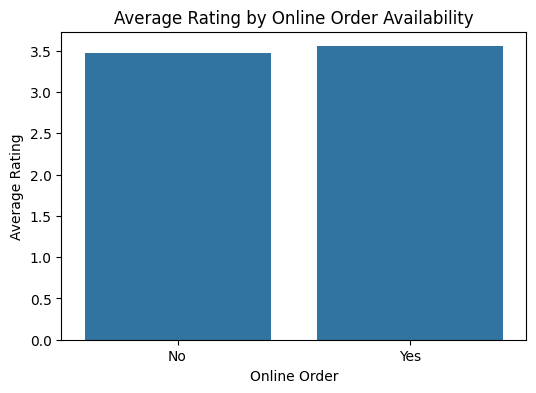

In [176]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=online_rating_sql,
    x="online_order",
    y="Avg_Rating"
)

plt.title("Average Rating by Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Average Rating")

plt.show()

In [177]:
query = """
SELECT [restaurant type],
       AVG([rate (out of 5)]) AS Avg_Rating
FROM zomato
GROUP BY [restaurant type]
HAVING COUNT(*) >= 20
ORDER BY Avg_Rating DESC
LIMIT 10;
"""

top_rated_types = pd.read_sql_query(
    query,
    conn
)

top_rated_types

,restaurant type,Avg_Rating
0,Fine Dining,4.116456
1,"Casual Dining, Cafe",4.028000
2,"Pub, Casual Dining",4.008000
3,"Bar, Casual Dining",3.907547
4,"Casual Dining, Bar",3.874380
5,Lounge,3.813793
6,Pub,3.782353
7,Cafe,3.693671
8,Bar,3.679012
9,Casual Dining,3.594691


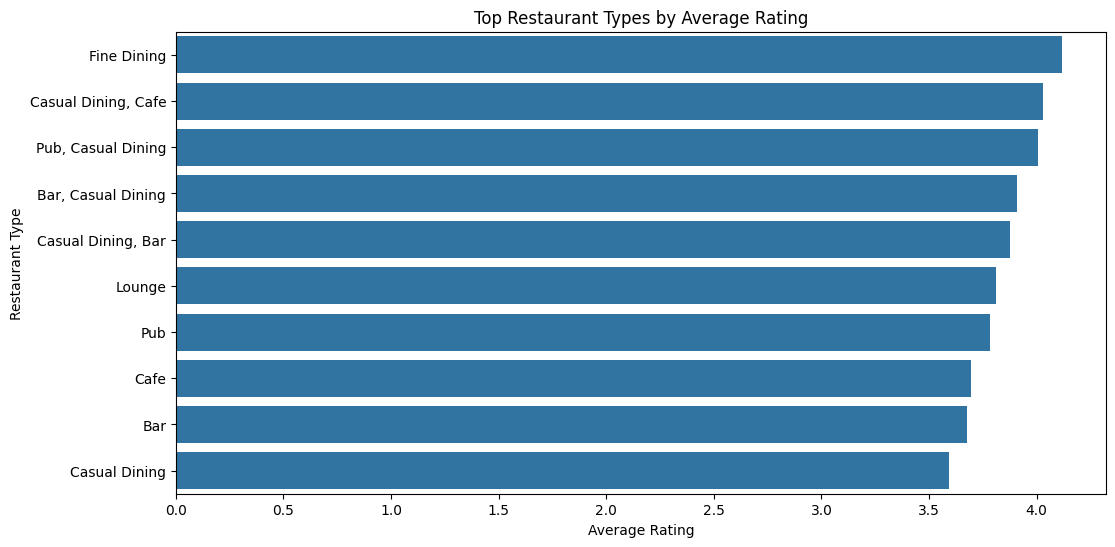

In [178]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated_types,
    x="Avg_Rating",
    y="restaurant type"
)

plt.title("Top Restaurant Types by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant Type")

plt.show()

In [179]:
query = """
SELECT [restaurant type],
       AVG([avg cost (two people)]) AS Avg_Cost
FROM zomato
GROUP BY [restaurant type]
ORDER BY Avg_Cost DESC
LIMIT 10;
"""

cost_sql = pd.read_sql_query(
    query,
    conn
)

cost_sql

,restaurant type,Avg_Cost
0,"Fine Dining, Microbrewery",3000.000000
1,"Fine Dining, Lounge",3000.000000
2,"Fine Dining, Bar",2862.500000
3,Fine Dining,2784.810127
4,"Bar, Lounge",2450.000000
5,"Club, Casual Dining",2400.000000
6,"Lounge, Microbrewery",2000.000000
7,Club,1940.000000
8,"Lounge, Casual Dining",1866.666667
9,"Lounge, Bar",1860.000000


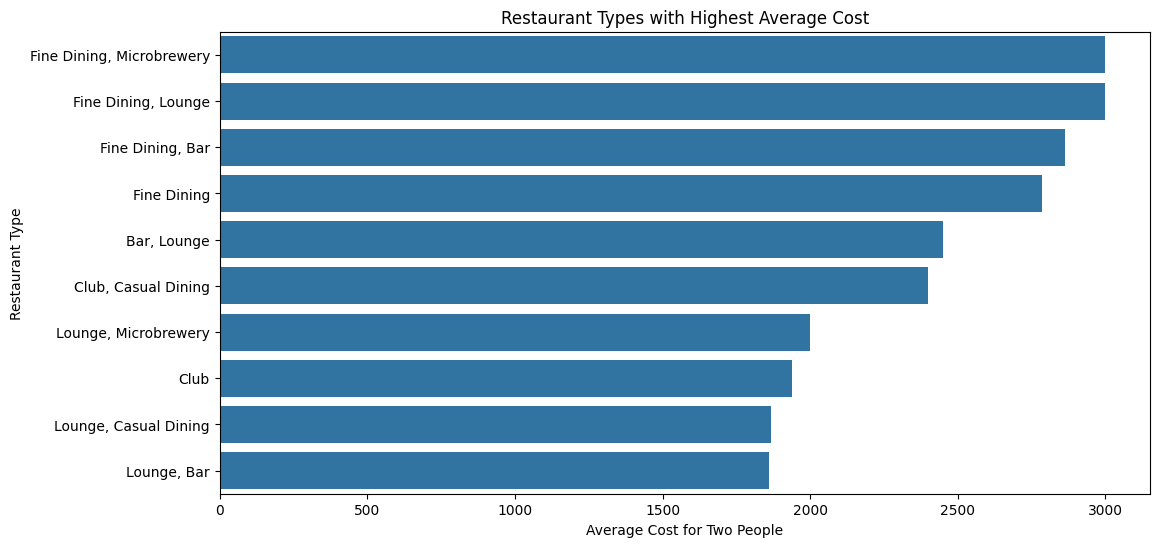

In [180]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=cost_sql,
    x="Avg_Cost",
    y="restaurant type"
)

plt.title("Restaurant Types with Highest Average Cost")
plt.xlabel("Average Cost for Two People")
plt.ylabel("Restaurant Type")

plt.show()

In [181]:
query = """
SELECT [table booking],
       AVG([rate (out of 5)]) AS Avg_Rating
FROM zomato
GROUP BY [table booking];
"""

booking_sql = pd.read_sql_query(
    query,
    conn
)

booking_sql

,table booking,Avg_Rating
0,No,3.452099
1,Yes,4.036022


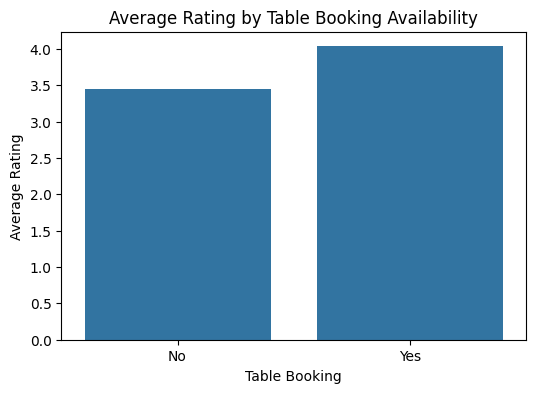

In [182]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=booking_sql,
    x="table booking",
    y="Avg_Rating"
)

plt.title("Average Rating by Table Booking Availability")
plt.xlabel("Table Booking")
plt.ylabel("Average Rating")

plt.show()

In [183]:
query = """
SELECT online_order,
       COUNT(*) AS Total_Restaurants
FROM zomato
GROUP BY online_order;
"""

online_count_sql = pd.read_sql_query(
    query,
    conn
)

online_count_sql

,online_order,Total_Restaurants
0,No,3263
1,Yes,3721


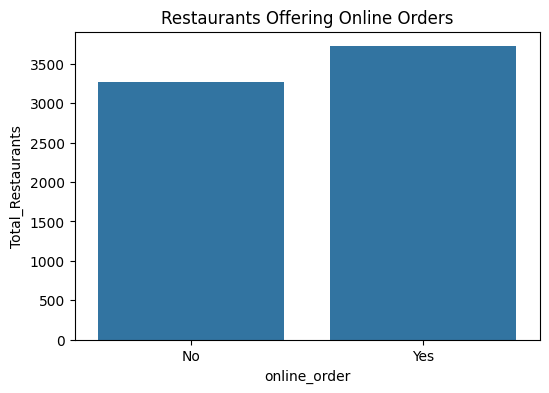

In [184]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=online_count_sql,
    x="online_order",
    y="Total_Restaurants"
)

plt.title("Restaurants Offering Online Orders")
plt.show()

In [185]:
top_areas_sql.to_csv(
    "../Dataset/top_areas.csv",
    index=False
)

In [186]:
top_rated_types.to_csv(
    "../Dataset/top_rated_types.csv",
    index=False
)

In [187]:
conn.close()
print("Database connection closed")

Database connection closed
